Saving pic7.jpg to pic7.jpg
Image loaded: pic7.jpg


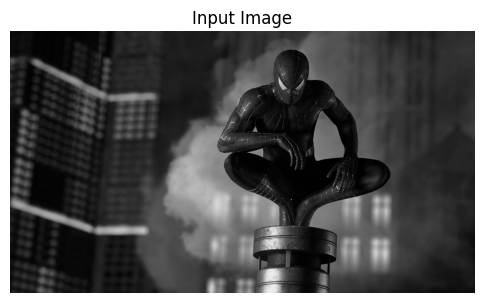

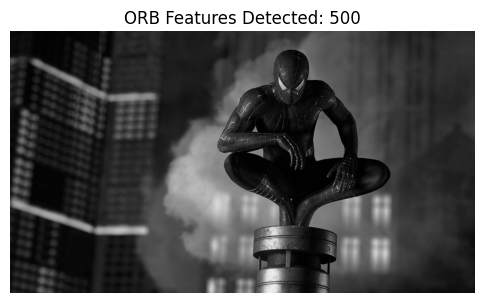

ORB Descriptor Shape: (500, 32)


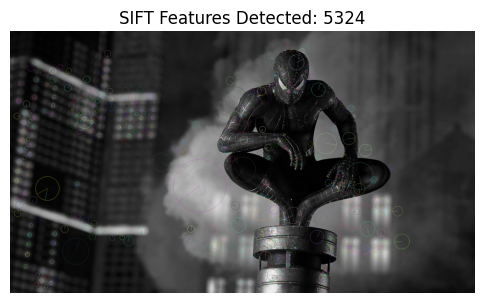

SIFT Descriptor Shape: (5324, 128)
❌ SURF not supported (Patent restriction in OpenCV)
===== FEATURE EXTRACTION SUMMARY =====
ORB  Features: 500
SIFT Features: 5324


In [1]:
# Feature Extraction and Feature Detection
# SIFT = Scale-Invariant Feature Transform
# ORB  = Oriented FAST and Rotated BRIEF
# SURF = Speeded-Up Robust Features

import cv2
import matplotlib.pyplot as plt
from google.colab import files


uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Image loaded:", image_path)

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap='gray')
plt.title("Input Image")
plt.axis("off")
plt.show()

orb = cv2.ORB_create(nfeatures=500)

kp_orb, des_orb = orb.detectAndCompute(gray, None)

orb_img = cv2.drawKeypoints(
    gray,
    kp_orb,
    None,
    flags=cv2.DrawMatchesFlags_DEFAULT
)

plt.figure(figsize=(6, 6))
plt.imshow(orb_img, cmap='gray')
plt.title(f"ORB Features Detected: {len(kp_orb)}")
plt.axis("off")
plt.show()

if des_orb is not None:
    print("ORB Descriptor Shape:", des_orb.shape)
else:
    print("No ORB descriptors found")

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect and compute
kp_sift, des_sift = sift.detectAndCompute(gray, None)

# Draw keypoints
sift_img = cv2.drawKeypoints(
    gray,
    kp_sift,
    None,
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
)

# Display SIFT result
plt.figure(figsize=(6, 6))
plt.imshow(sift_img, cmap='gray')
plt.title(f"SIFT Features Detected: {len(kp_sift)}")
plt.axis("off")
plt.show()

if des_sift is not None:
    print("SIFT Descriptor Shape:", des_sift.shape)
else:
    print("No SIFT descriptors found")

try:
    surf = cv2.xfeatures2d.SURF_create(400)
    kp_surf, des_surf = surf.detectAndCompute(gray, None)

    surf_img = cv2.drawKeypoints(
        gray,
        kp_surf,
        None,
        flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(surf_img, cmap='gray')
    plt.title(f"SURF Features Detected: {len(kp_surf)}")
    plt.axis("off")
    plt.show()

    if des_surf is not None:
        print("SURF Descriptor Shape:", des_surf.shape)
    else:
        print("No SURF descriptors found")

except:
    print("❌ SURF not supported (Patent restriction in OpenCV)")

print("===== FEATURE EXTRACTION SUMMARY =====")
print("ORB  Features:", len(kp_orb))
print("SIFT Features:", len(kp_sift))
